Цель проекта: провести анализ данных о продажах магазина электроники и аксессуаров за 2024 год для выявления ключевых драйверов выручки, анализа сезонности и сегментации товарного портфеля. 

Датасет содержит информацию о 5 104 транзакциях, включая данные о заказах, клиентах, товарах, регионах продаж, каналах сбыта и финансовых показателях.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Настройка визуализации
plt.style.use('ggplot')
np.random.seed(42)

In [3]:
df = pd.read_excel(r"C:\Users\user45\Documents\Учеба\Анализ\1\sales_data.xlsx")
df

,order_id,date,customer_id,product,region,channel,quantity,unit_price
0,ORD-10000,01/05/2024,CUST-6876,Keyboard,South,Online,1,309
1,ORD-10000,01/05/2024,CUST-6876,Mouse,West,Online,3,55
2,ORD-10000,01/05/2024,CUST-6876,Headphones,East,Online,2,384
3,ORD-10001,11/30/2024,CUST-4012,Keyboard,North,Online,5,155
4,ORD-10001,11/30/2024,CUST-4012,Mouse,South,Partner,5,27
...,...,...,...,...,...,...,...,...
5099,ORD-11516,04/01/2024,CUST-4411,Headphones,North,Retail,3,151
5100,ORD-10429,02/26/2024,CUST-3504,Mouse,North,Partner,4,52
5101,ORD-11507,12/02/2024,CUST-8063,Phone,North,Partner,5,1078
5102,ORD-11176,02/20/2024,CUST-6657,Headphones,South,Online,4,150


### Подготовка данных

In [4]:
# Очистка данных
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"Обнаружено дубликатов: {duplicate_count}.")
    df = df.drop_duplicates()

print(f"Размер датасета после очистки: {len(df)}")

Обнаружено дубликатов: 100.
Размер датасета после очистки: 5004


In [5]:
# Рассчет выручки
df["revenue"] = df["quantity"] * df["unit_price"]

In [6]:
df

,order_id,date,customer_id,product,region,channel,quantity,unit_price,revenue
0,ORD-10000,01/05/2024,CUST-6876,Keyboard,South,Online,1,309,309
1,ORD-10000,01/05/2024,CUST-6876,Mouse,West,Online,3,55,165
2,ORD-10000,01/05/2024,CUST-6876,Headphones,East,Online,2,384,768
3,ORD-10001,11/30/2024,CUST-4012,Keyboard,North,Online,5,155,775
4,ORD-10001,11/30/2024,CUST-4012,Mouse,South,Partner,5,27,135
...,...,...,...,...,...,...,...,...,...
4999,ORD-12498,05/19/2024,CUST-4745,Headphones,South,Online,4,118,472
5000,ORD-12498,05/19/2024,CUST-4745,Mouse,East,Partner,5,149,745
5001,ORD-12498,05/19/2024,CUST-4745,Monitor,North,Retail,1,930,930
5002,ORD-12499,07/01/2024,CUST-1001,Keyboard,South,Retail,5,204,1020


### EDA (Исследовательский анализ) 

In [7]:
print("--- Первичный обзор данных ---")
print(df.info())
print(f"\nПропущенные значения:\n{df.isnull().sum()}")

--- Первичный обзор данных ---
<class 'pandas.DataFrame'>
RangeIndex: 5004 entries, 0 to 5003
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   order_id     5004 non-null   str  
 1   date         5004 non-null   str  
 2   customer_id  5004 non-null   str  
 3   product      5004 non-null   str  
 4   region       5004 non-null   str  
 5   channel      5004 non-null   str  
 6   quantity     5004 non-null   int64
 7   unit_price   5004 non-null   int64
 8   revenue      5004 non-null   int64
dtypes: int64(3), str(6)
memory usage: 578.9 KB
None

Пропущенные значения:
order_id       0
date           0
customer_id    0
product        0
region         0
channel        0
quantity       0
unit_price     0
revenue        0
dtype: int64


In [8]:
# Изменяем формат даты 
df['date'] = pd.to_datetime(df['date'])

# Сортировка
df = df.sort_values('date')

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 5004 entries, 222 to 1030
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     5004 non-null   str           
 1   date         5004 non-null   datetime64[us]
 2   customer_id  5004 non-null   str           
 3   product      5004 non-null   str           
 4   region       5004 non-null   str           
 5   channel      5004 non-null   str           
 6   quantity     5004 non-null   int64         
 7   unit_price   5004 non-null   int64         
 8   revenue      5004 non-null   int64         
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 568.4 KB


In [10]:
df = df.reset_index(drop=True)

### Исследование выручки и сезонных паттернов

C:\Users\user45\AppData\Local\Temp\ipykernel_3916\3592660519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, palette="viridis")


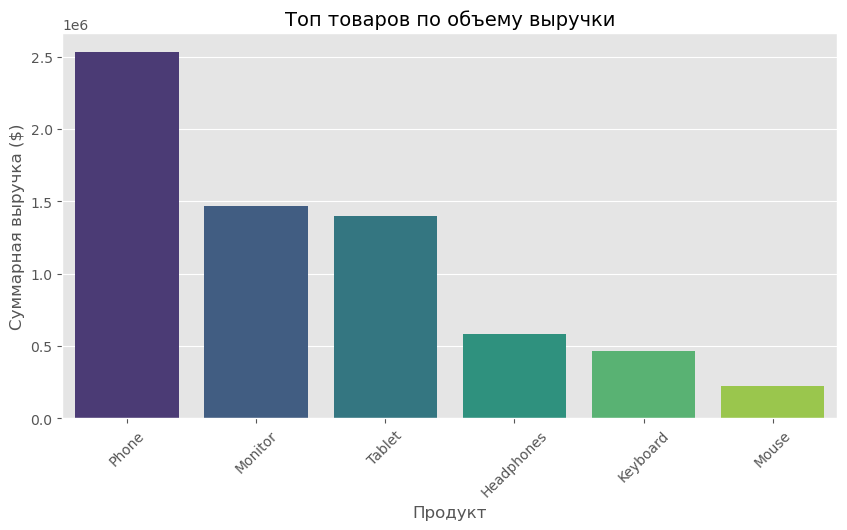

In [11]:
# Анализ товаров по объему выручки
top_products = df.groupby("product")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.index, y=top_products.values, palette="viridis")
plt.title("Топ товаров по объему выручки", fontsize=14)
plt.ylabel("Суммарная выручка ($)")
plt.xlabel("Продукт")
plt.xticks(rotation=45)
plt.show()

Товары категории Phone занимает лидирующую позицию с максимальной суммарной выручкой. Данный товар является основным драйвером продаж и требует особого внимания с точки зрения маркетинга, наличия на складе и ассортиментной политики. Monitor и Tablet уступают лидеру, но обеспечивают существенную долю выручки и диверсифицируют доходы компании. Headphones, Keyboard и Mouse показывают наименьшие показатели выручки. Это может быть связано с: низкой ценой товаров (аксессуары дешевле основной электроники), меньшим спросом, недостаточной маркетинговой активностью.

In [12]:
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.day_name()

# Выручка в день
daily_revenue = df.groupby('date')['revenue'].sum()          
# Выручка за месяц
monthly_revenue = df.groupby('month')['revenue'].sum()        
# Средняя выручка в день внутри месяца
monthly_avg_daily = df.groupby('month')['revenue'].mean()     
# Общая выручка за год
total_revenue = df['revenue'].sum()                           

print(f"Общая выручка за год: ${total_revenue:,.0f}")
print(f"Средняя выручка в день: ${daily_revenue.mean():,.0f}")
print(f"Медианная выручка в день: ${daily_revenue.median():,.0f}")

Общая выручка за год: $6,676,907
Средняя выручка в день: $18,293
Медианная выручка в день: $17,590


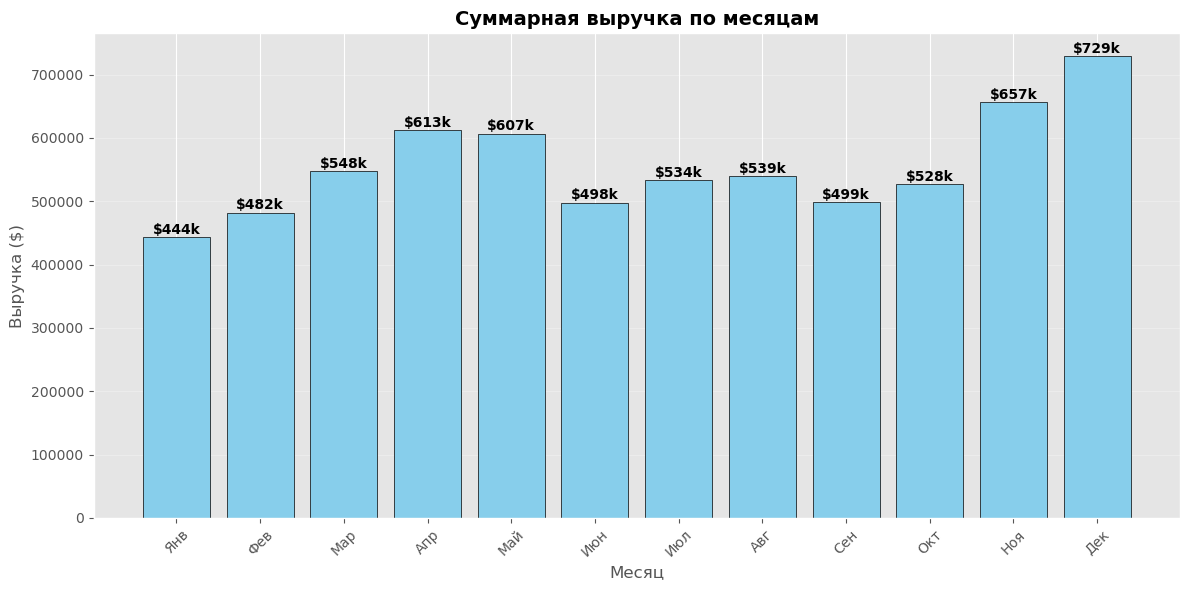

In [14]:
# Суммарная выручка по месяцам
plt.figure(figsize=(12, 6))

bars = plt.bar(range(1, 13), monthly_revenue.values, color='skyblue', edgecolor='black')
plt.title('Суммарная выручка по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Выручка ($)', fontsize=12)
plt.xticks(range(1, 13), ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек'], rotation=45)

# Добавляем подписи на столбцы
for i, v in enumerate(monthly_revenue.values):
    plt.text(i + 1, v + 5000, f'${v/1000:.0f}k', ha='center', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

График демонстрирует сезонность продаж с пиками в апреле-мае и ноябре-декабре, а так же спадами в январе, феврале, июне и сентябре. Что характерно для сезонных распродаж, маркетинговых акций, праздничных периодов. Необходимо стимулировать спрос в периоды спада. В периоды пиков возможно усиление маркетинговой политики для повышения результатов.

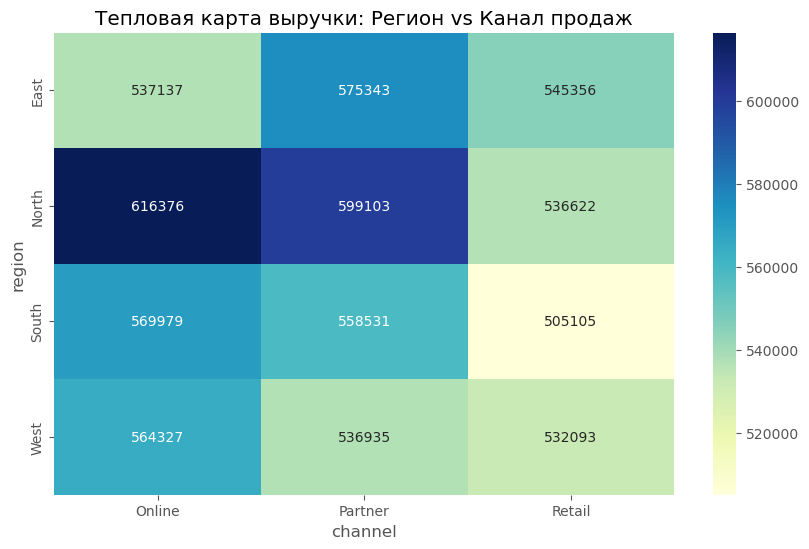

In [15]:
# Тепловая карта продаж по регионам и каналам
pivot_table = df.pivot_table(index='region', columns='channel', values='revenue', aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Тепловая карта выручки: Регион vs Канал продаж")
plt.show()

In [16]:
# Индекс концентрации (HHI) по регионам и товарам: показывает, насколько равномерно распределена выручка.
def hhi(df, group_col, value_col='revenue'):
    shares = df.groupby(group_col)[value_col].sum() / df[value_col].sum()
    return (shares**2).sum()

print(f"HHI по регионам: {hhi(df, 'region'):.3f}")  # >0.25 = высокая концентрация
print(f"HHI по товарам: {hhi(df, 'product'):.3f}")

HHI по регионам: 0.250
HHI по товарам: 0.250


Значение HHI по регионам (0.250) находится на границе между средней и высокой концентрацией. Это означает, что выручка умеренно неравномерно распределена между регионами: нет региона-монополиста, но есть заметное доминирование некоторых территорий. Бизнес не зависит от одного региона и риски диверсифицированы по территории. Но есть регионы, которые приносят существенно больше выручки. Поэтому при проблемах в регионе-лидере (экономический спад, стихийное бедствие) бизнес может понести потери. Необходимо развивать продажи в отстающих регионах для снижения концентрации до < 0.20. 
Значение HHI по товарам (0.250) также находится на границе средней и высокой концентрации. Выручка умеренно неравномерно распределена между товарными категориями, есть товары-«локомотивы», но нет товара-монополиста, ассортимент диверсифицирован и нет критической зависимости от одного товара. Но падение спроса на топ-товары может сильно ударить по бизнесу.

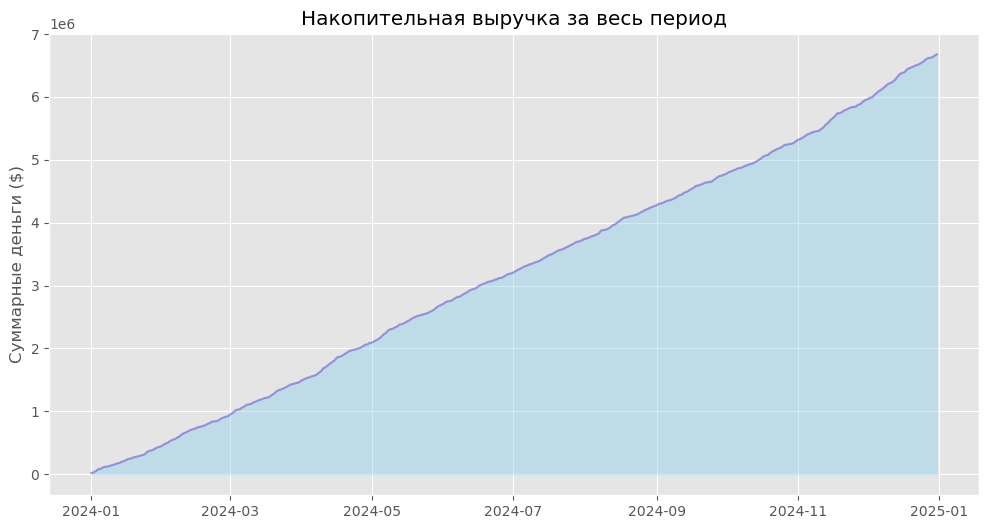

In [17]:
# Кумулятивная выручка
daily_revenue = df.groupby('date')['revenue'].sum().reset_index()
daily_revenue['cumulative_revenue'] = daily_revenue['revenue'].cumsum()

plt.figure(figsize=(12, 6))
plt.fill_between(daily_revenue['date'], daily_revenue['cumulative_revenue'], color="skyblue", alpha=0.4)
plt.plot(daily_revenue['date'], daily_revenue['cumulative_revenue'], color="Slateblue", alpha=0.6)
plt.title("Накопительная выручка за весь период")
plt.ylabel("Суммарные деньги ($)")
plt.show()

Кривая кумулятивной выручки имеет устойчивую восходящую траекторию без остановок роста.

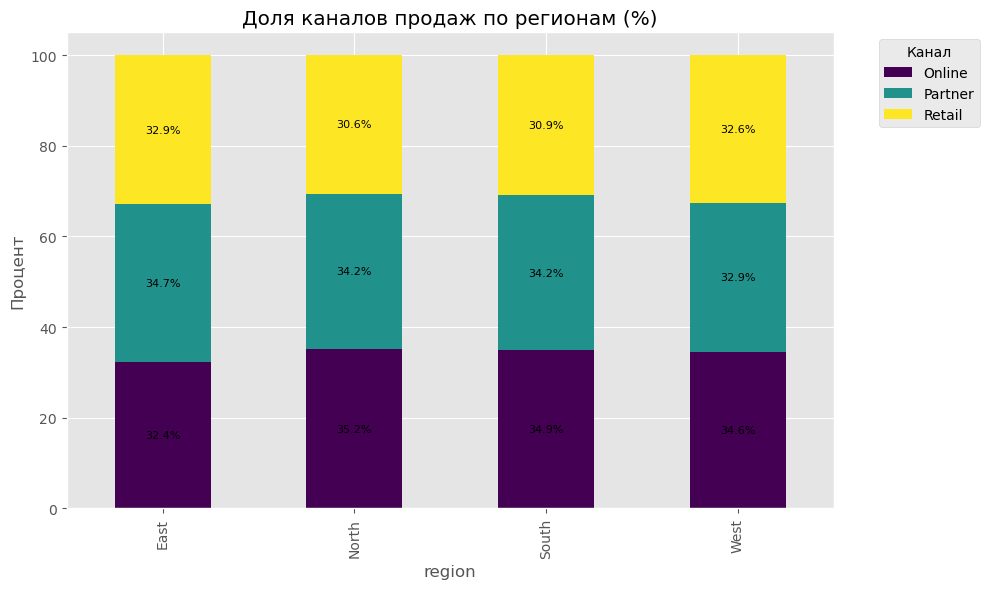

In [18]:
# Доля каждого канала в выручке по регионам (stacked bar)
channel_region_pct = df.pivot_table(index='region', columns='channel', values='revenue', aggfunc='sum', fill_value=0)
channel_region_pct = channel_region_pct.div(channel_region_pct.sum(axis=1), axis=0) * 100

ax = channel_region_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')

# Добавляем подписи процентов на каждый сегмент
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

plt.title('Доля каналов продаж по регионам (%)')
plt.ylabel('Процент')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [20]:
print("Доли каналов по регионам (%):")
print(channel_region_pct.round(2))

Доли каналов по регионам (%):
channel  Online  Partner  Retail
region                          
East      32.40    34.70   32.90
North     35.18    34.19   30.63
South     34.89    34.19   30.92
West      34.55    32.87   32.58


На основе анализа долей каналов продаж по регионам можно сделать следующие выводы:
1. Распределение выручки по каналам продаж в разрезе регионов достаточно равномерное — ни один канал не доминирует существенно. Во всех регионах доли Online, Partner и Retail находятся примерно в диапазоне 30–35%.
2. В регионах North и South наблюдается небольшое преимущество канала Online (около 35%), что может указывать на более высокую цифровую активность клиентов.
3. В регионе East лидирует канал Partner (34.7%), что говорит о сильной роли партнерской сети.
4. В регионе West распределение наиболее сбалансированное, без явного лидера.

В целом структура продаж по каналам стабильна между регионами, что может означать либо одинаковую стратегию продвижения, либо схожее поведение клиентов. При этом небольшие различия можно использовать для точечной оптимизации каналов в каждом регионе (например, усиление наиболее эффективного канала).

In [21]:
# Анализ кросс-продаж (какие товары покупают вместе)

order_products = df.groupby('order_id')['product'].agg(list)
from itertools import combinations
from collections import Counter

pairs = []
for products in order_products:
    if len(products) > 1:
        pairs.extend(combinations(sorted(products), 2))
        
pair_counts = Counter(pairs)
print("Топ-5 пар товаров:", pair_counts.most_common(5))

Топ-5 пар товаров: [(('Keyboard', 'Mouse'), 218), (('Headphones', 'Mouse'), 208), (('Keyboard', 'Tablet'), 204), (('Mouse', 'Phone'), 201), (('Phone', 'Tablet'), 199)]


Анализ кросс-продаж показывает устойчивые и логичные паттерны совместных покупок, что отражает поведение клиентов и дополняемость товаров:
1. Самая частая комбинация — Keyboard + Mouse (218). Это ожидаемо, так как эти товары функционально связаны и часто покупаются вместе.
2. Пары Headphones + Mouse (208) и Mouse + Phone (201) указывают на то, что мышь часто выступает как «дополняющий» товар в разных сценариях покупки.
3. Покупатели склонны приобретать аксессуары вместе с основными устройствами или комбинировать взаимодополняющие товары. Это хорошая возможность для:
- создания бандлов (например, клавиатура + мышь),
- рекомендаций "с этим товаром покупают",
- увеличения среднего чека за счет кросс-продаж.
Можно дополнительно усилить продажи, предлагая такие пары через персонализированные рекомендации или акции.

Таким образом, бизнес демонстрирует стабильный рост и хорошую диверсификацию, при этом сохраняет зависимость от ключевых товаров. Общая выручка ($6.7 млн) и ровная кумулятивная динамика подтверждают устойчивость модели, однако внутри структуры есть точки роста и риски.

Главным драйвером остается категория Phone, формирующая значительную часть дохода. При этом другие категории (Monitor, Tablet) поддерживают баланс, а аксессуары (Keyboard, Mouse, Headphones) играют важную роль в увеличении среднего чека через кросс-продажи, несмотря на более низкую индивидуальную выручку.

С точки зрения сезонности, продажи подвержены выраженным колебаниям: пики приходятся на периоды активного спроса (весна и конец года), а спады — на начало и середину года. Это указывает на необходимость более активного управления спросом в «низкие» периоды и максимизации прибыли в пиковые месяцы.

Анализ концентрации (HHI ≈ 0.25) показывает умеренный уровень риска: нет критической зависимости от одного региона или товара, но есть заметные лидеры, от которых бизнес частично зависит. Это означает, что компании важно продолжать стратегию диверсификации — развивать отстающие регионы и усиливать менее прибыльные категории.

Структура каналов продаж сбалансирована по всем регионам, что говорит о зрелой и устойчивой модели дистрибуции. При этом небольшие различия можно использовать для локальной оптимизации и повышения эффективности отдельных каналов.

Анализ кросс-продаж выявил сильные связи между товарами, особенно между устройствами и аксессуарами. Это открывает значительный потенциал для увеличения среднего чека, внедрения бандлов, персонализированных рекомендаций.

Бизнес находится в устойчивом состоянии с хорошей базой для масштабирования. Основные направления роста — это:
- снижение зависимости от топ-товаров и регионов,
- активизация продаж в периоды спада,
- развитие кросс-продаж и работы с аксессуарами,
- точечная оптимизация каналов по регионам.

При реализации этих шагов компания может не только снизить риски, но и значительно увеличить выручку без кардинального изменения бизнес-модели.